# S2DR4 Super-Resolution — Khartoum, Sudan

This notebook super-resolves Sentinel-2 imagery from **10m to 1m/pixel** using Gamma Earth's S2DR4 model.

**Before running:** Go to `Runtime → Change runtime type → T4 GPU`

### Output Products (1m resolution, 4×4 km area):
| File | Description |
|------|-------------|
| `_MS.tif` | 10-band multispectral (B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12) |
| `_TCI.tif` | True color RGB |
| `_NDVI.tif` | Vegetation index |
| `_IRP.tif` | Infrared pseudo-color |

## 1. Mount Google Drive, Verify GPU & Install S2DR4

In [9]:
# =========================================================
# LOCAL COLAB OUTPUT (NO GOOGLE DRIVE)
# =========================================================

import os

# Local output folder inside Colab VM
OUTPUT_DIR = "/content/output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Output will be saved temporarily to:\n{OUTPUT_DIR}")

# =========================================================
# VERIFY GPU
# =========================================================

!echo ""
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

# =========================================================
# CLEAN OLD PACKAGES
# =========================================================

print("\nCleaning conflicting packages...")

!pip uninstall -y numpy scipy s2dr4

# =========================================================
# INSTALL COMPATIBLE NUMPY / SCIPY
# =========================================================

print("\nInstalling compatible NumPy/SciPy stack...")

!pip install -q --no-cache-dir \
    "numpy==2.2.6" \
    "scipy==1.14.1"

# =========================================================
# INSTALL S2DR4
# =========================================================

print("\nInstalling S2DR4...")

!pip install -q --no-cache-dir \
    https://storage.googleapis.com/0x7ff601307fa5/s2dr4-20260126.1-cp312-cp312-linux_x86_64.whl

# =========================================================
# IMPORTANT
# =========================================================

print("\nInstall complete.")
print("IMPORTANT:")
print("Go to Runtime → Restart runtime")
print("Then run the notebook again from the top.")

Output will be saved temporarily to:
/content/output

Tesla T4, 15360 MiB

Cleaning conflicting packages...
Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Found existing installation: scipy 1.14.1
Uninstalling scipy-1.14.1:
  Successfully uninstalled scipy-1.14.1
Found existing installation: s2dr4 20260126.1
Uninstalling s2dr4-20260126.1:
  Successfully uninstalled s2dr4-20260126.1

Installing compatible NumPy/SciPy stack...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 195.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 334.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 330.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 req

## 2. Configure Location & Date

Edit the coordinates and date below for your area of interest.

In [10]:
# ──── CONFIGURATION ────────────────────────────────────────
# Custom AOI
# Input point:
#   Lat:  2.411796
#   Lon: -78.420542
#
# S2DR4 format is (Longitude, Latitude) — NOTE: X, Y order!
LONLAT = (-78.420542, 2.411796)

# Target date
# S2DR4 picks the closest available Sentinel-2 scene
# Archive available from 2018-01-01 onward
DATE = '2026-02-04'
# ──────────────────────────────────────────────────────────

print(f"Location : Custom AOI")
print(f"Lon/Lat  : {LONLAT}")
print(f"Date     : {DATE}")
print(f"Area     : 4 × 4 km")
print(f"Output   : 1 m/px (10× super-resolution)")

Location : Custom AOI
Lon/Lat  : (-78.420542, 2.411796)
Date     : 2026-02-04
Area     : 4 × 4 km
Output   : 1 m/px (10× super-resolution)


## 3. Run Super-Resolution Inference

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 2.2.6
SciPy: 1.14.1
S2DR4 import successful.

Trying S2DR4 inference for date: 2026-02-04
Location: (-78.420542, 2.411796)
Preprocessing T17NQC-97741c4bd-20250808 (69)  done.
Preprocessing T17NQC-97741c4bd-20260130 (90) xxxxxxxx.xxx.x Alignment failed.
Preprocessing T17NQC-97741c4bd-20250922 (75) xxxxxxxxxxxxxx Alignment failed.
Preprocessing T17NQC-97741c4bd-20250823 (93) xxxxxxxxxxxxxx Alignment failed.
 done.

FAILED for 2026-02-04: IndexError
Likely no usable aligned Sentinel-2 scene for this AOI/date.
Trying next date...

Trying S2DR4 inference for date: 2026-01-30
Location: (-78.420542, 2.411796)
Preprocessing T17NQC-97741c4bd-20250808 (69)  done.
Preprocessing T17NQC-97741c4bd-20260130 (90) xxx..xxxxxxxxx Alignment failed.
Preprocessing T17NQC-97741c4bd-20250922 (75) xxxxxxxxxx.xxx Alignment failed.
Preprocessing T17NQC-97741c4bd-20250823 (93) xxx.xxxxxxxx.x Alignment failed.
 done.

FAILED for 2026-01-30: IndexEr

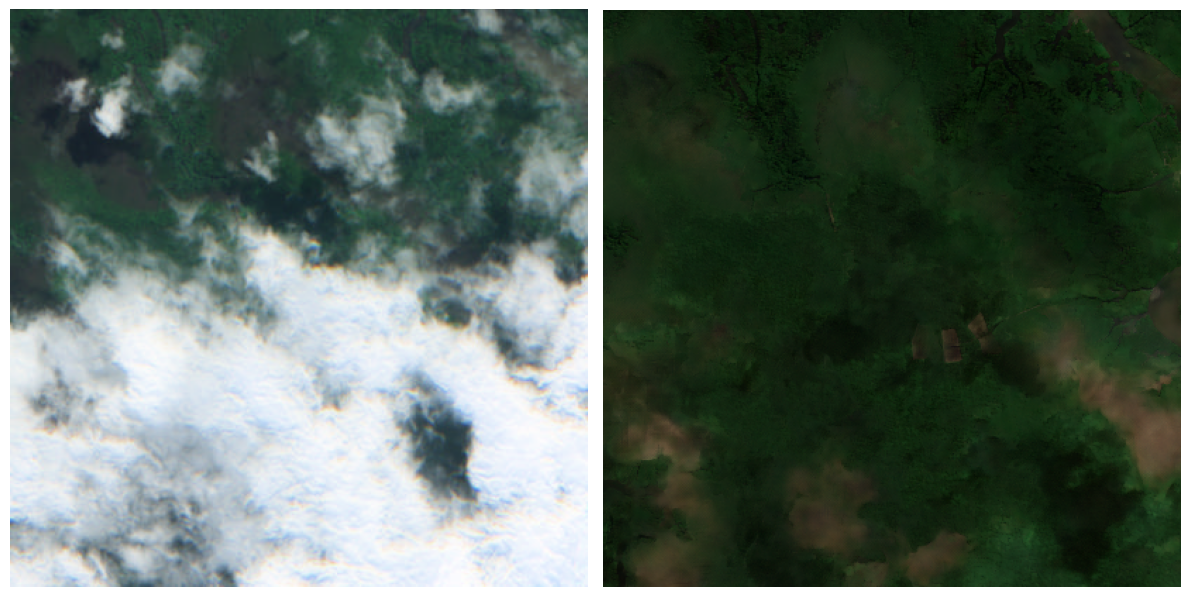


SUCCESS: S2DR4 inference complete for 2025-10-25


In [11]:
# =========================================================
# BLOCK 3 — RUN S2DR4 INFERENCE WITH DATE FALLBACKS
# =========================================================

import sys
import traceback
import s2dr4.inferutils

print("Python:", sys.version)

import numpy as np
import scipy

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("S2DR4 import successful.")

# Try multiple dates near your target.
# S2DR4 will still pick nearby Sentinel-2 scenes internally.
DATES_TO_TRY = [
    "2026-02-04",
    "2026-01-30",
    "2026-01-20",
    "2026-01-10",
    "2025-12-25",
    "2025-12-10",
    "2025-11-25",
    "2025-11-10",
    "2025-10-25",
    "2025-10-10",
    "2025-09-22",
    "2025-09-10",
    "2025-08-23",
    "2025-08-08",
]

success = False

for test_date in DATES_TO_TRY:
    print("\n" + "=" * 70)
    print(f"Trying S2DR4 inference for date: {test_date}")
    print(f"Location: {LONLAT}")
    print("=" * 70)

    try:
        s2dr4.inferutils.test(LONLAT, test_date)
        print(f"\nSUCCESS: S2DR4 inference complete for {test_date}")
        success = True
        break

    except IndexError as e:
        print(f"\nFAILED for {test_date}: IndexError")
        print("Likely no usable aligned Sentinel-2 scene for this AOI/date.")
        print("Trying next date...")

    except Exception as e:
        print(f"\nFAILED for {test_date}: {type(e).__name__}")
        print(e)
        print("Trying next date...")

if not success:
    raise RuntimeError(
        "S2DR4 failed for all attempted dates. "
        "Try moving the AOI slightly inland or choosing a much clearer/drier season date."
    )

## 4. List & Preview Results

In [12]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = '/content/output'
tif_files = sorted(f for f in os.listdir(OUTPUT_DIR) if f.endswith('.tif'))

print("Generated files (saved to Google Drive):")
print("-" * 60)
for f in tif_files:
    fpath = os.path.join(OUTPUT_DIR, f)
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    with rasterio.open(fpath) as ds:
        print(f"  {f}")
        print(f"    {ds.width}x{ds.height} px, {ds.count} bands, {size_mb:.1f} MB")

print()
print(f"Results saved to: /content/drive/MyDrive/Gamma Earth S2DR4/output")

Generated files (saved to Google Drive):
------------------------------------------------------------

Results saved to: /content/drive/MyDrive/Gamma Earth S2DR4/output


OUTPUT_DIR: /content/output
Exists: True

Files currently in OUTPUT_DIR:
output/
  CO/
    T17NQC/
      T17NQC-97741c4bd/
        S2L3Ax10_T17NQC-97741c4bd-20250729_TCI.tif
        S2L3Ax10_T17NQC-97741c4bd-20250716_NDVI.tif
        S2L3Ax10_T17NQC-97741c4bd-20250729_MS.tif
        S2L3Ax10_T17NQC-97741c4bd-20250729_IRP.tif
        S2L3Ax10_T17NQC-97741c4bd-20250716_IRP.tif
        S2L3Ax10_T17NQC-97741c4bd-20250716_MS.tif
        S2L3Ax10_T17NQC-97741c4bd-20250729_NDVI.tif
        S2L3Ax10_T17NQC-97741c4bd-20250716_TCI.tif

All TIFs found:
  /content/output/CO/T17NQC/T17NQC-97741c4bd/S2L3Ax10_T17NQC-97741c4bd-20250729_TCI.tif
  /content/output/CO/T17NQC/T17NQC-97741c4bd/S2L3Ax10_T17NQC-97741c4bd-20250716_NDVI.tif
  /content/output/CO/T17NQC/T17NQC-97741c4bd/S2L3Ax10_T17NQC-97741c4bd-20250729_MS.tif
  /content/output/CO/T17NQC/T17NQC-97741c4bd/S2L3Ax10_T17NQC-97741c4bd-20250729_IRP.tif
  /content/output/CO/T17NQC/T17NQC-97741c4bd/S2L3Ax10_T17NQC-97741c4bd-20250716_IRP.tif
  /content/o

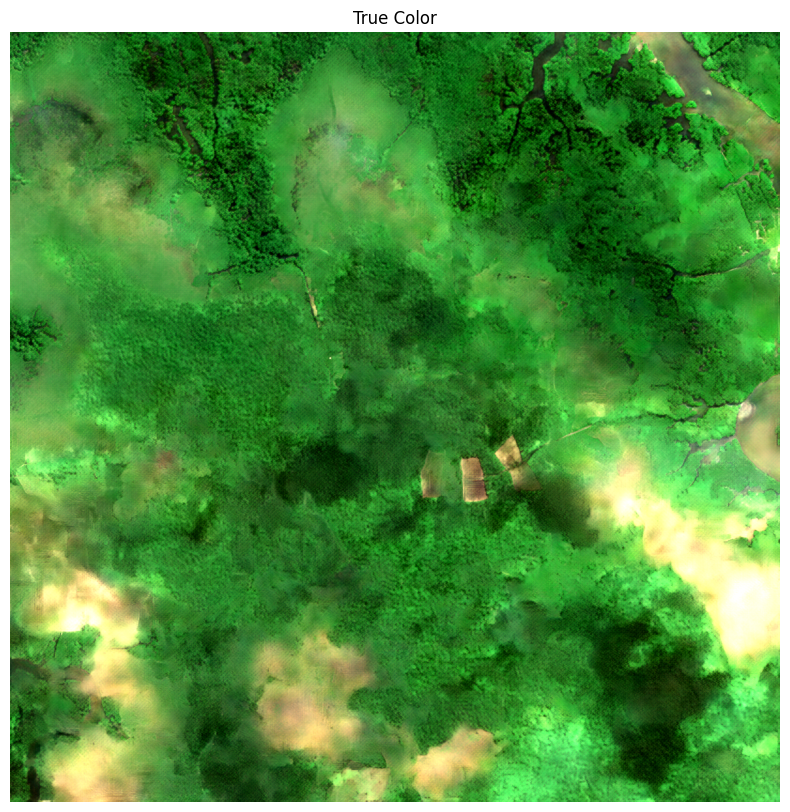

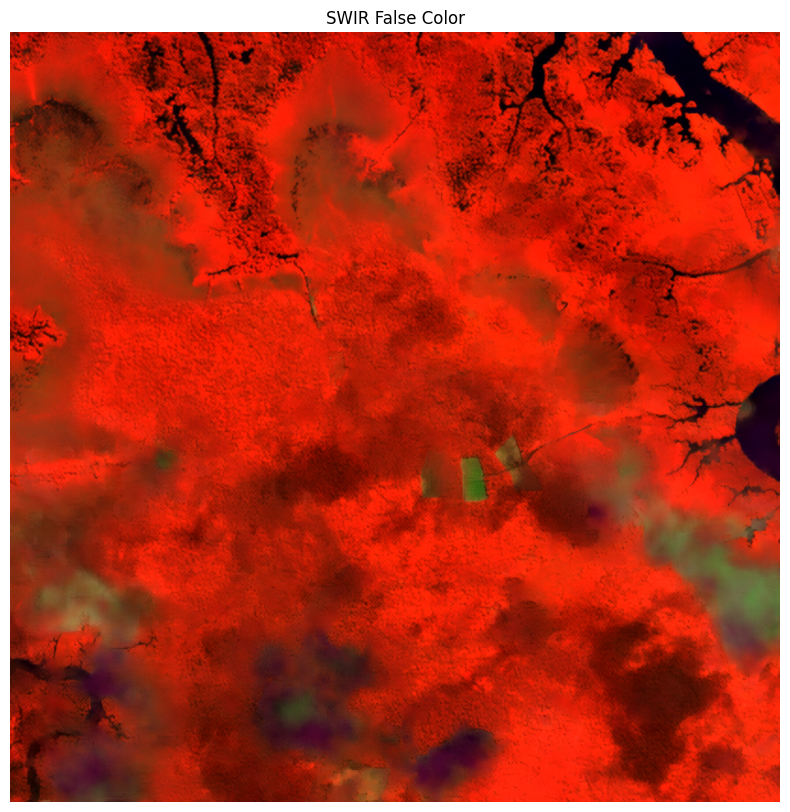

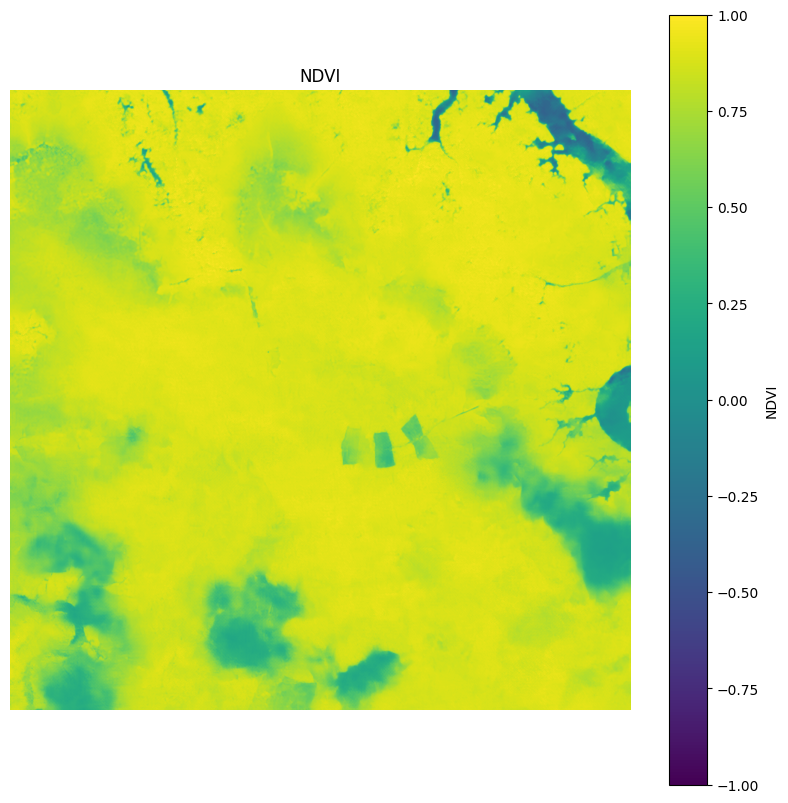

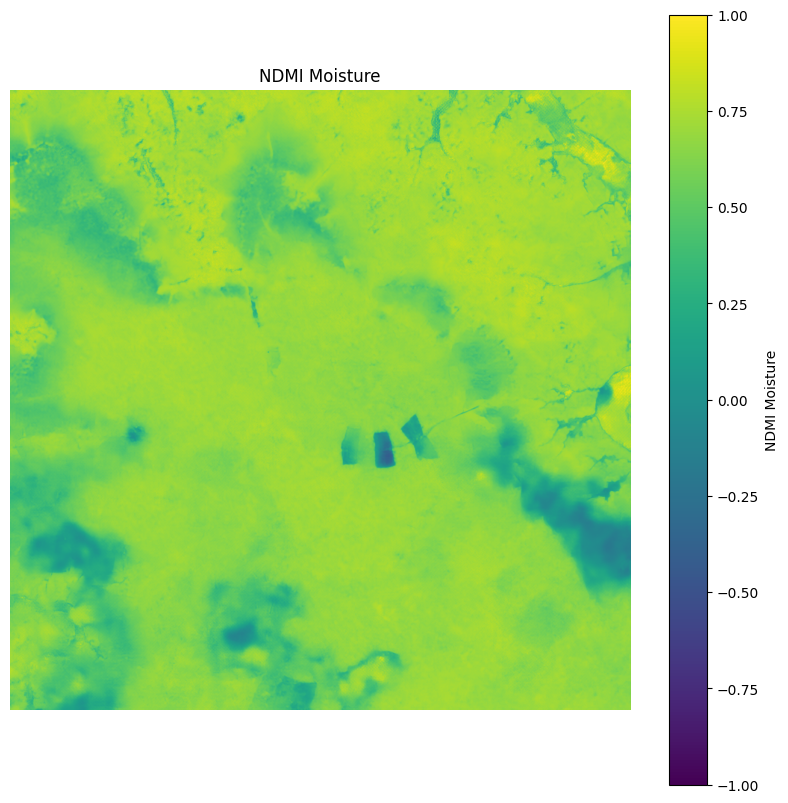

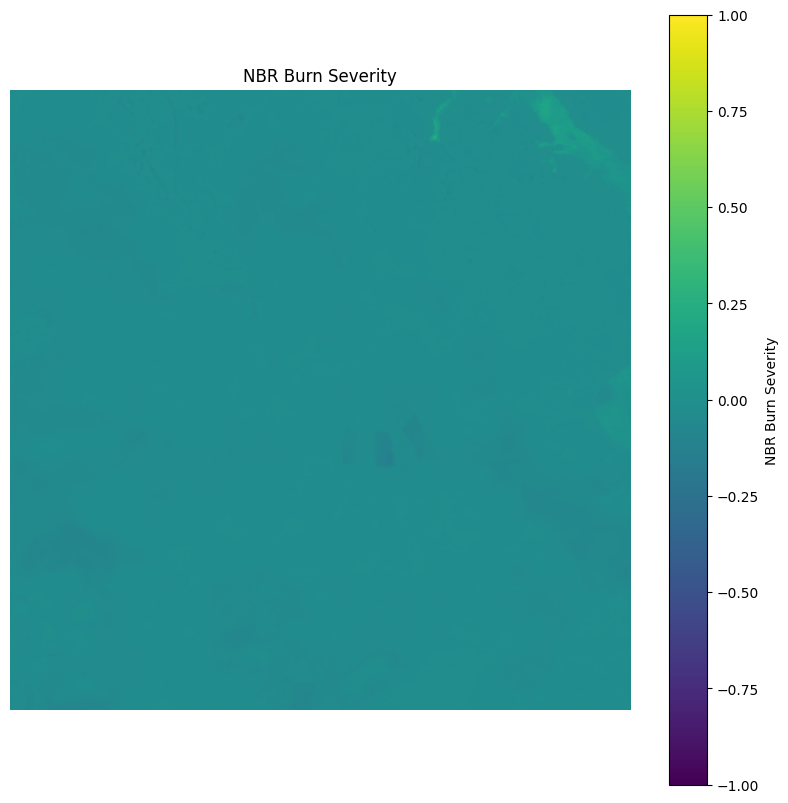

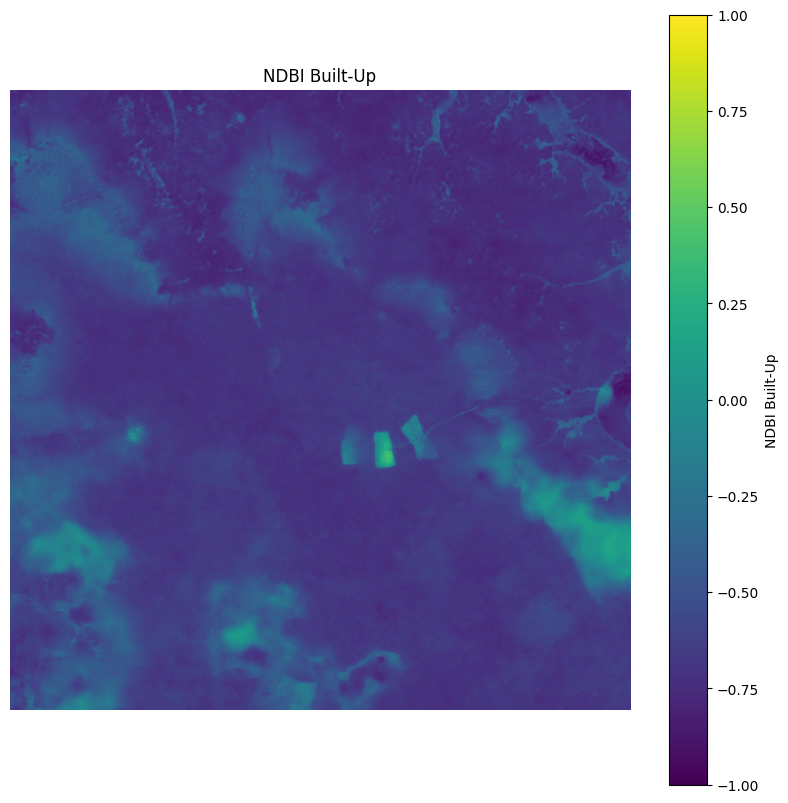


DONE.
Derived products written to:
/content/output/derived_products


In [13]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# FIND MS FILE — DIAGNOSTIC VERSION
# =========================================================

print("OUTPUT_DIR:", OUTPUT_DIR)
print("Exists:", os.path.exists(OUTPUT_DIR))

print("\nFiles currently in OUTPUT_DIR:")

for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for f in files:
        print(f"{indent}  {f}")

# =========================================================
# SEARCH RECURSIVELY FOR ALL TIFF FILES
# =========================================================

all_tifs = []

for root, dirs, files in os.walk(OUTPUT_DIR):
    for f in files:
        if f.lower().endswith((".tif", ".tiff")):
            all_tifs.append(os.path.join(root, f))

print("\nAll TIFs found:")

for f in all_tifs:
    print(" ", f)

# =========================================================
# FIND MULTISPECTRAL FILE
# =========================================================

ms_files = [
    f for f in all_tifs
    if "_MS" in os.path.basename(f)
    or "MS" in os.path.basename(f)
]

if not ms_files:
    raise RuntimeError(
        "No multispectral MS GeoTIFF found.\n"
        "S2DR4 likely did not complete successfully."
    )

ms_path = ms_files[0]

print("\nUsing MS file:")
print(ms_path)

# =========================================================
# OUTPUT FOLDER FOR DERIVED PRODUCTS
# =========================================================

DERIVED_DIR = os.path.join(OUTPUT_DIR, "derived_products")
os.makedirs(DERIVED_DIR, exist_ok=True)

print("\nDerived output folder:")
print(DERIVED_DIR)

# =========================================================
# HELPERS
# =========================================================

def safe_index(a, b):
    return (a - b) / (a + b + 1e-6)

def stretch_rgb(arr):
    p2, p98 = np.nanpercentile(arr, [2, 98])
    return np.clip((arr - p2) / (p98 - p2 + 1e-6), 0, 1)

def save_single_band(path, array, profile, nodata=-9999):

    out = array.astype("float32")
    out = np.where(np.isfinite(out), out, nodata)

    prof = profile.copy()

    prof.update(
        count=1,
        dtype="float32",
        nodata=nodata,
        compress="LZW",
        BIGTIFF="IF_SAFER"
    )

    with rasterio.open(path, "w", **prof) as dst:
        dst.write(out, 1)

def save_rgb(path, rgb, profile):

    out = rgb.astype("float32")

    prof = profile.copy()

    prof.update(
        count=3,
        dtype="float32",
        nodata=None,
        compress="LZW",
        BIGTIFF="IF_SAFER"
    )

    with rasterio.open(path, "w", **prof) as dst:
        dst.write(np.moveaxis(out, -1, 0))

# =========================================================
# LOAD MULTISPECTRAL DATA
# =========================================================

with rasterio.open(ms_path) as ds:

    profile = ds.profile.copy()

    print("\nRaster info:")
    print("Width :", ds.width)
    print("Height:", ds.height)
    print("Bands :", ds.count)

    # S2DR4 _MS band order:
    # 1=B2
    # 2=B3
    # 3=B4
    # 4=B5
    # 5=B6
    # 6=B7
    # 7=B8
    # 8=B8A
    # 9=B11
    # 10=B12

    blue   = ds.read(1).astype("float32")
    green  = ds.read(2).astype("float32")
    red    = ds.read(3).astype("float32")
    red_e1 = ds.read(4).astype("float32")
    red_e2 = ds.read(5).astype("float32")
    red_e3 = ds.read(6).astype("float32")
    nir    = ds.read(7).astype("float32")
    nir_n  = ds.read(8).astype("float32")
    swir1  = ds.read(9).astype("float32")
    swir2  = ds.read(10).astype("float32")

# =========================================================
# RGB / FALSE COLOR COMPOSITES
# =========================================================

print("\nGenerating RGB composites...")

true_color = stretch_rgb(np.dstack([red, green, blue]))

false_color_veg = stretch_rgb(
    np.dstack([nir, red, green])
)

swir_false_color = stretch_rgb(
    np.dstack([swir2, swir1, red])
)

urban_false_color = stretch_rgb(
    np.dstack([swir1, swir2, red])
)

agriculture_color = stretch_rgb(
    np.dstack([swir1, nir, blue])
)

save_rgb(
    os.path.join(DERIVED_DIR, "True_Color_RGB_1m.tif"),
    true_color,
    profile
)

save_rgb(
    os.path.join(DERIVED_DIR, "False_Color_Vegetation_1m.tif"),
    false_color_veg,
    profile
)

save_rgb(
    os.path.join(DERIVED_DIR, "SWIR_False_Color_1m.tif"),
    swir_false_color,
    profile
)

save_rgb(
    os.path.join(DERIVED_DIR, "Urban_False_Color_1m.tif"),
    urban_false_color,
    profile
)

save_rgb(
    os.path.join(DERIVED_DIR, "Agriculture_False_Color_1m.tif"),
    agriculture_color,
    profile
)

# =========================================================
# INDICES
# =========================================================

print("\nGenerating indices...")

ndvi = safe_index(nir, red)
ndmi = safe_index(nir, swir1)
nbr  = safe_index(nir, swir2)
ndwi = safe_index(green, nir)
mndwi = safe_index(green, swir1)
ndbi = safe_index(swir1, nir)

savi = (
    1.5 * (nir - red)
    / (nir + red + 0.5 + 1e-6)
)

ndre = safe_index(nir_n, red_e1)

clay_ratio = swir1 / (swir2 + 1e-6)
ferrous_ratio = swir1 / (nir + 1e-6)
swir_ratio = swir2 / (swir1 + 1e-6)

# =========================================================
# SAVE INDEX TIFFS
# =========================================================

save_single_band(
    os.path.join(DERIVED_DIR, "NDVI_1m.tif"),
    ndvi,
    profile
)

save_single_band(
    os.path.join(DERIVED_DIR, "NDMI_Moisture_1m.tif"),
    ndmi,
    profile
)

save_single_band(
    os.path.join(DERIVED_DIR, "NBR_Burn_Severity_1m.tif"),
    nbr,
    profile
)

save_single_band(
    os.path.join(DERIVED_DIR, "NDWI_Water_1m.tif"),
    ndwi,
    profile
)

save_single_band(
    os.path.join(DERIVED_DIR, "MNDWI_Modified_Water_1m.tif"),
    mndwi,
    profile
)

save_single_band(
    os.path.join(DERIVED_DIR, "NDBI_Built_Up_1m.tif"),
    ndbi,
    profile
)

save_single_band(
    os.path.join(DERIVED_DIR, "SAVI_1m.tif"),
    savi,
    profile
)

save_single_band(
    os.path.join(DERIVED_DIR, "NDRE_1m.tif"),
    ndre,
    profile
)

save_single_band(
    os.path.join(DERIVED_DIR, "Clay_Ratio_1m.tif"),
    clay_ratio,
    profile
)

save_single_band(
    os.path.join(DERIVED_DIR, "Ferrous_Ratio_1m.tif"),
    ferrous_ratio,
    profile
)

save_single_band(
    os.path.join(DERIVED_DIR, "SWIR_Ratio_1m.tif"),
    swir_ratio,
    profile
)

# =========================================================
# QUICK PREVIEWS
# =========================================================

preview_items = [
    ("True Color", true_color, None),
    ("SWIR False Color", swir_false_color, None),
    ("NDVI", ndvi, (-1, 1)),
    ("NDMI Moisture", ndmi, (-1, 1)),
    ("NBR Burn Severity", nbr, (-1, 1)),
    ("NDBI Built-Up", ndbi, (-1, 1)),
]

print("\nRendering previews...")

for title, data, limits in preview_items:

    plt.figure(figsize=(10, 10))

    if data.ndim == 3:

        plt.imshow(data)

    else:

        if limits:
            plt.imshow(
                data,
                vmin=limits[0],
                vmax=limits[1]
            )
        else:
            plt.imshow(data)

        plt.colorbar(label=title)

    plt.title(title)
    plt.axis("off")
    plt.show()

print("\nDONE.")
print("Derived products written to:")
print(DERIVED_DIR)

## 5. Download Results

Results are **already saved to your Google Drive** at:
```
Google Drive/Gamma Earth S2DR4/output/
```
They will sync automatically to your PC if you have Google Drive desktop installed.

Run the cell below **only** if you want a direct browser download as well.

In [14]:
import os
import shutil
from google.colab import files

# =========================================================
# ZIP SETTINGS
# =========================================================

zip_name = "S2DR4_SuperRes_Output"

# Folder to ZIP
SOURCE_FOLDER = OUTPUT_DIR

# Temporary ZIP location inside Colab VM
zip_base = f"/content/{zip_name}"
zip_path = f"{zip_base}.zip"

# =========================================================
# CREATE ZIP
# =========================================================

print("Creating ZIP archive...")
print(f"Source folder: {SOURCE_FOLDER}")

shutil.make_archive(
    zip_base,
    "zip",
    SOURCE_FOLDER
)

# =========================================================
# REPORT SIZE
# =========================================================

size_mb = os.path.getsize(zip_path) / (1024 * 1024)

print(f"\nZIP complete:")
print(f"  {zip_path}")
print(f"  Size: {size_mb:.1f} MB")

# =========================================================
# DOWNLOAD TO LOCAL PC
# =========================================================

print("\nStarting browser download...")

files.download(zip_path)

Creating ZIP archive...
Source folder: /content/output

ZIP complete:
  /content/S2DR4_SuperRes_Output.zip
  Size: 1905.8 MB

Starting browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
*Powered by [Gamma Earth S2DR4](https://medium.com/@ya_71389/c71a601a2253) — Sentinel-2 Deep Resolution 4.0*